# Overview

The goal of this section was to use song lyrics to predict genre labels. This section used a new dataset from the Million Song Dataset website: http://millionsongdataset.com/

The lyric data was downloaded as a SQLite database from here:
http://millionsongdataset.com/musixmatch/

The genre data was downloaded as a text file from here (CD2C):
https://www.tagtraum.com/msd_genre_datasets.html

The two datasets both had a `track_id` column, which was used to combine them. 

At a high level, the following steps were taken:
1. The lyrics were filtered (removed stop words, non-english words, non-nouns, uncommon words, and short words)
2. The lyrics were converted to "text document" format (a track corresponds to a document)
3. The document format lyrics were combined with genre labels to form supervised learning samples
4. The samples were balanced according to genre
5. The samples were split into feature-label sets, then split into train-test sets
6. The train-test feature sets were converted to "Bag of Words" format, and then they were converted into TF-IDF matrices
7. Scikit-learn's SVC was used with Linear, RBF, and Polynomial kernels on a sample of the training set, then LinearSVC was used on the full training set (optimized for big dataset), and finally Boosting was used as an ensemble method (used LightGBM, since it was a lot faster than XGBoost)

# Data Prep

## Initialization

### Install packages

In [ ]:
%pip install langdetect
%pip install nltk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 18.2 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993225 sha256=fab471b3b6f3be37960571932e6c402a95bed28f3410596ba67b86a472a792cc
  Stored in directory: /Users/michael/Library/Caches/pip/wheels/c4/16/af/1889804d8b7c0c041cadee8e29673a938a332acbf2865c70a1
Successfully built langdetect
Note: you may need to restart the kernel to use updated packages.


### Import modules

In [ ]:
import sqlite3
import pandas as pd
import nltk
from nltk.corpus import stopwords
from langdetect import detect, DetectorFactory

DetectorFactory.seed = 0

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/michael/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/michael/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/michael/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

### Confusion matrix plotter

In [ ]:
from matplotlib import pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = [4, 3]

def plot_confusion_matrix(test_y, pred_y):
    cm = confusion_matrix(test_y, pred_y)
    disp = ConfusionMatrixDisplay(cm, display_labels=test_y.unique())
    custom_cmap = LinearSegmentedColormap.from_list(
        'black_to_seagreen', ['black', 'seagreen', 'mediumseagreen', 'mediumspringgreen']
    )
    disp.plot(cmap=custom_cmap)
    plt.title('Confusion Matrix', fontsize=11)
    plt.xlabel('Predicted label', fontsize=9)
    plt.ylabel('True label', fontsize=9)
    plt.xticks(fontsize=7, rotation=90)
    plt.yticks(fontsize=7)
    for text in disp.text_.ravel():
        text.set_fontsize(8)
    plt.show()

## Preprocessing

### Get lyrics from SQL database

To create random2.db, these SQL commands were used\
(the 250000 part was a smaller random sample at first):

```
$ sqlite3

> ATTACH 'mxm_dataset.db' AS mxm;

> ATTACH DATABASE 'random2.db' AS random2;

> CREATE TABLE random2.words AS
> SELECT * FROM mxm.words;

> CREATE temp TABLE temp_tracks AS
> SELECT DISTINCT track_id FROM mxm.lyrics ORDER BY random() LIMIT 250000;

> CREATE TABLE random2.lyrics AS
> SELECT * FROM mxm.lyrics
> WHERE track_id IN (SELECT track_id FROM temp_tracks);

> DETACH DATABASE random2;
> .quit
```

In [ ]:
# lyrics data: http://millionsongdataset.com/musixmatch/
# you need a lot of storage, RAM, and compute power to handle this dataset, it doesn't work well on coding.csel servers
conn = sqlite3.connect('random2.db')
lyrics_df = pd.read_sql_query('SELECT track_id, lower(word) as word, "count" FROM lyrics', conn)
conn.close()

print(lyrics_df.shape)
lyrics_df.head()

This dataset has 19,045,332 rows and 237,662 unique tracks.

### Remove non-English tracks (takes over 10 minutes)

In [ ]:
# join track lyrics before language detection
def join_words(track):
    return ' '.join(track.nlargest(100, 'count')['word'])

temp_lyrics = lyrics_df.groupby('track_id').apply(join_words)

# detect the language of each track
track_languages = {}
for track_id, text in temp_lyrics.items():
    try:
        lang = detect(text)
        track_languages[track_id] = lang
    except:
        track_languages[track_id] = 'unknown'

# remove non-english tracks
english_tracks = {track_id for track_id, lang in track_languages.items() if lang == 'en'}
lyrics_df = lyrics_df[lyrics_df['track_id'].isin(english_tracks)]
print(lyrics_df.shape)

(17094972, 3)


Checkpoint (save lyrics_df which now mostly only has English tracks):

In [ ]:
lyrics_df.to_csv('english_lyrics.csv', index=False)

In [ ]:
lyrics_df = pd.read_csv('english_lyrics.csv')
lyrics_df.head()

,track_id,word,count
0,TRAAAAV128F421A322,i,6
1,TRAAAAV128F421A322,the,4
2,TRAAAAV128F421A322,you,2
3,TRAAAAV128F421A322,to,2
4,TRAAAAV128F421A322,and,5


### Remove stop words and only keep most common words

In [ ]:
# total word counts in lyrics
word_counts = lyrics_df.groupby('word')['count'].sum().sort_values(ascending=False)

# remove stop words
stop_words = set(stopwords.words('english'))
filtered_word_counts = word_counts[~word_counts.index.isin(stop_words)]

# top 5000 most common words
top_words = set(filtered_word_counts.head(5000).index)

len(top_words)

4865

### Remove short words and words that aren't nouns

In [187]:
# features set will be the columns (words) in the bag of words matrix

# remove short words
features = {word for word in top_words if len(word) > 3}

# only keep nouns
tagged_words = nltk.pos_tag(list(features))
features = {word for word, tag in tagged_words if tag.startswith('N')}

len(features)

2686

### Format track lyrics as text documents

In [ ]:
def track_to_document(track):
    words = track.loc[track['word'].isin(features)]

    # a word can be inserted multiple times based on its count (snow, 2 -> "snow snow")
    document = ' '.join([word for word, count in zip(words['word'], words['count']) for i in range(count)])
    
    return document

documents = lyrics_df.groupby('track_id').apply(track_to_document)

In [244]:
print(documents.shape)
documents.head()

(199173,)


track_id
TRAAAAV128F421A322    someon pass river piec damn grace somehow igno...
TRAAABD128F429CF47    time time time heart heart heart heart heart n...
TRAAAED128E0783FAB    love love love love love love love love love l...
TRAAAEF128F4273421    world girl girl girl girl girl girl girl girl ...
TRAAAEW128F42930C0    stay someon breath bodi bodi bodi bodi bodi bo...
dtype: object

### Combine track documents (lyrics) and genre labels

In [ ]:
import pandas as pd
from sklearn.utils import resample

# load genres
genre_df = pd.read_csv('msd_tagtraum_cd2c.cls', sep='\t', comment='#', header=None, names=['track_id', 'genre'])

# filter samples to subset of genre labels
genres = ['Country', 'Rap', 'Pop', 'Metal', 'Electronic', 'Jazz', 'Reggae']
genre_df = genre_df[genre_df['genre'].isin(genres)].reset_index(drop=True)

# merge lyric documents and genre label
documents_df = documents.reset_index()
documents_df.columns = ['track_id', 'lyrics']
merged_df = pd.merge(documents_df, genre_df, on='track_id')

# sample each genre
max_samples = 7000
balanced_genres = []

for genre in merged_df['genre'].unique():
    genre_subset_df = merged_df[merged_df['genre'] == genre]
    # sample without replacement only if there are more samples than max_samples
    samples = resample(
        genre_subset_df,
        replace=(len(genre_subset_df) < max_samples),
        n_samples=max_samples,
        random_state=1
    )
    balanced_genres.append(samples)

# recombine the samples
balanced_df = pd.concat(balanced_genres).reset_index(drop=True)

print(balanced_df['genre'].value_counts())
display(balanced_df.head())

Jazz          7000
Rap           7000
Metal         7000
Reggae        7000
Pop           7000
Electronic    7000
Country       7000
Name: genre, dtype: int64


,track_id,lyrics,genre
0,TRQQOZU128E0796A1D,time time time time time time life need need n...,Jazz
1,TRDGGXD128F93358D4,time time babi babi babi babi babi babi babi b...,Jazz
2,TRRFPSQ128F92CAB96,love love love heart heart night onli onli onl...,Jazz
3,TROELBR128F9337F74,heart night look caus gotta gotta gotta mine f...,Jazz
4,TRKXDGV128F92D1ABF,love love love love love love love love tomorr...,Jazz


### Train-test split

In [ ]:
from sklearn.model_selection import train_test_split

# X-y split
X = balanced_df['lyrics']
y = balanced_df['genre']

# train-test split with statify=y to make classes even 
train_X, test_X, train_y, test_y = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=1,
)

print(f'Training samples: {len(train_X)}')
print(f'Testing samples: {len(test_X)}')

Training samples: 39200
Testing samples: 9800


### Convert documents to Bag of Words, then to TFIDF matrix

In [247]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.preprocessing import normalize

# fit on training samples, then transform test samples
count_vectorizer = CountVectorizer()
train_X_bow = count_vectorizer.fit_transform(train_X)
test_X_bow = count_vectorizer.transform(test_X)

tfidf_transformer = TfidfTransformer()
train_X_tfidf = tfidf_transformer.fit_transform(train_X_bow)
test_X_tfidf = tfidf_transformer.transform(test_X_bow)

# normalize each row
train_X_tfidf = normalize(train_X_tfidf)
test_X_tfidf = normalize(test_X_tfidf)

print(f'Train: {train_X_tfidf.shape}')
print(f'Test: {test_X_tfidf.shape}')

Train: (39200, 2450)
Test: (9800, 2450)


## Modeling

### Use Kernel SVM to predict genre based on lyrics (samples 10,000 rows)

Linear Kernel
	Accuracy: 0.583
	Average F1: 0.587

              precision    recall  f1-score   support

        Jazz       0.59      0.51      0.55      1400
         Rap       0.45      0.50      0.47      1400
       Metal       0.57      0.60      0.59      1400
      Reggae       0.66      0.64      0.65      1400
         Pop       0.41      0.46      0.43      1400
  Electronic       0.88      0.79      0.83      1400
     Country       0.60      0.57      0.59      1400

    accuracy                           0.58      9800
   macro avg       0.59      0.58      0.59      9800
weighted avg       0.59      0.58      0.59      9800



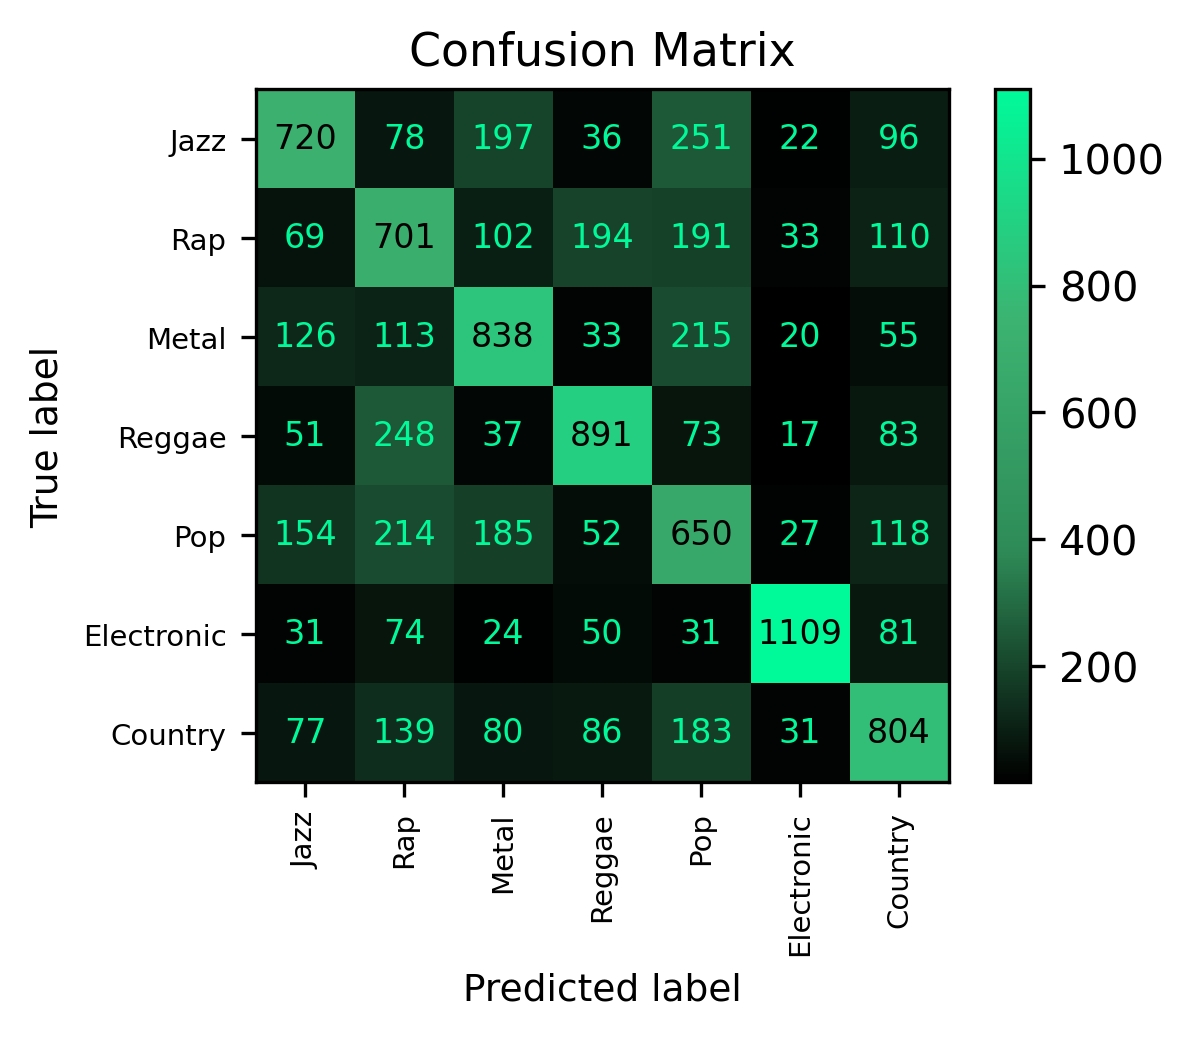

RBF Kernel
	Accuracy: 0.662
	Average F1: 0.666

              precision    recall  f1-score   support

        Jazz       0.66      0.59      0.62      1400
         Rap       0.51      0.59      0.55      1400
       Metal       0.73      0.71      0.72      1400
      Reggae       0.71      0.70      0.71      1400
         Pop       0.47      0.54      0.50      1400
  Electronic       0.89      0.82      0.85      1400
     Country       0.73      0.68      0.71      1400

    accuracy                           0.66      9800
   macro avg       0.67      0.66      0.67      9800
weighted avg       0.67      0.66      0.67      9800



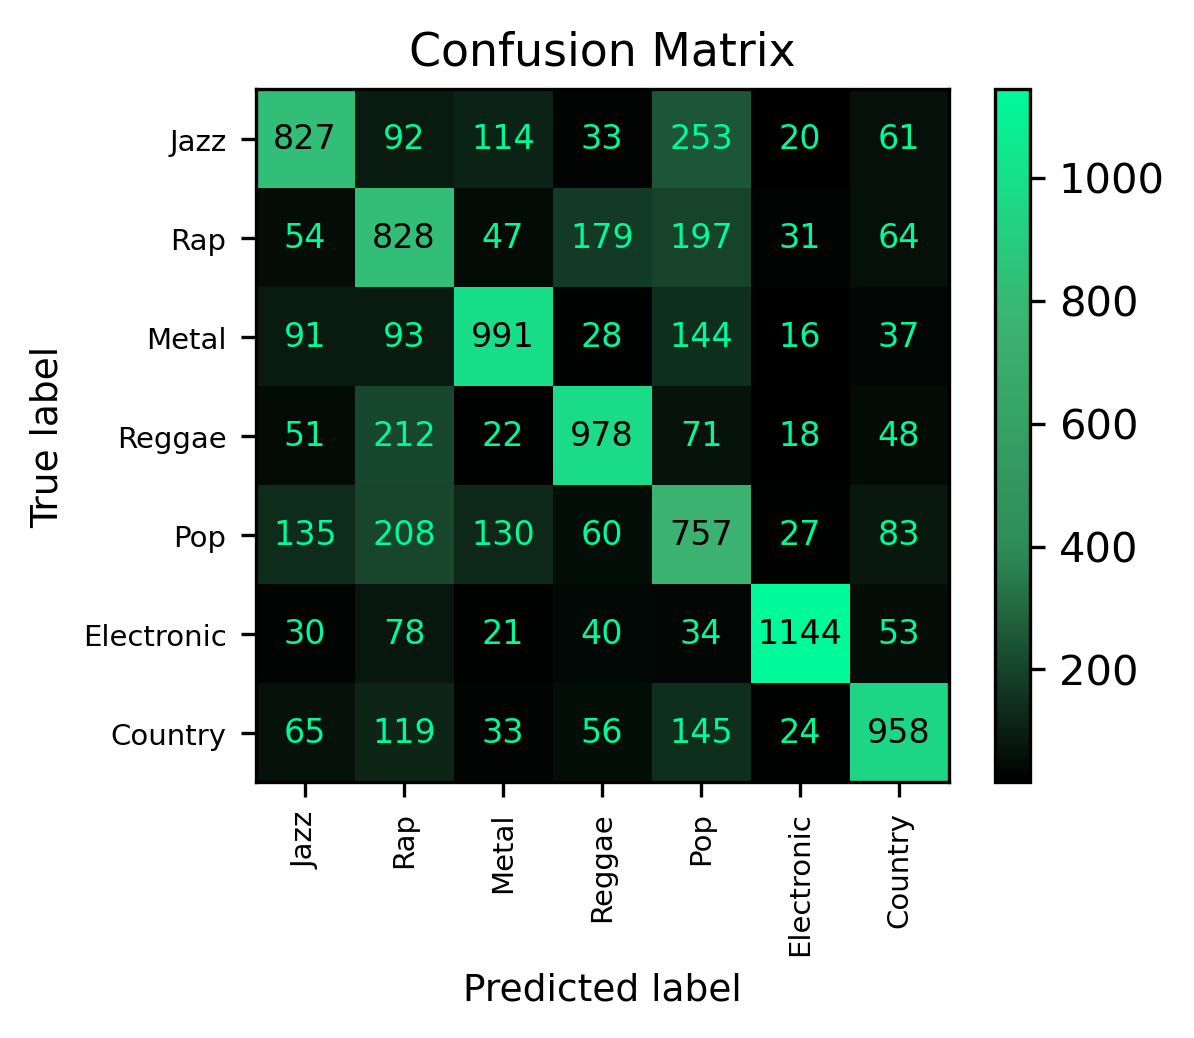

Polynomial Kernel with degree of 2
	Accuracy: 0.654
	Average F1: 0.658

              precision    recall  f1-score   support

        Jazz       0.64      0.58      0.61      1400
         Rap       0.49      0.58      0.53      1400
       Metal       0.77      0.70      0.73      1400
      Reggae       0.66      0.72      0.69      1400
         Pop       0.47      0.52      0.50      1400
  Electronic       0.88      0.79      0.83      1400
     Country       0.75      0.68      0.71      1400

    accuracy                           0.65      9800
   macro avg       0.67      0.65      0.66      9800
weighted avg       0.67      0.65      0.66      9800



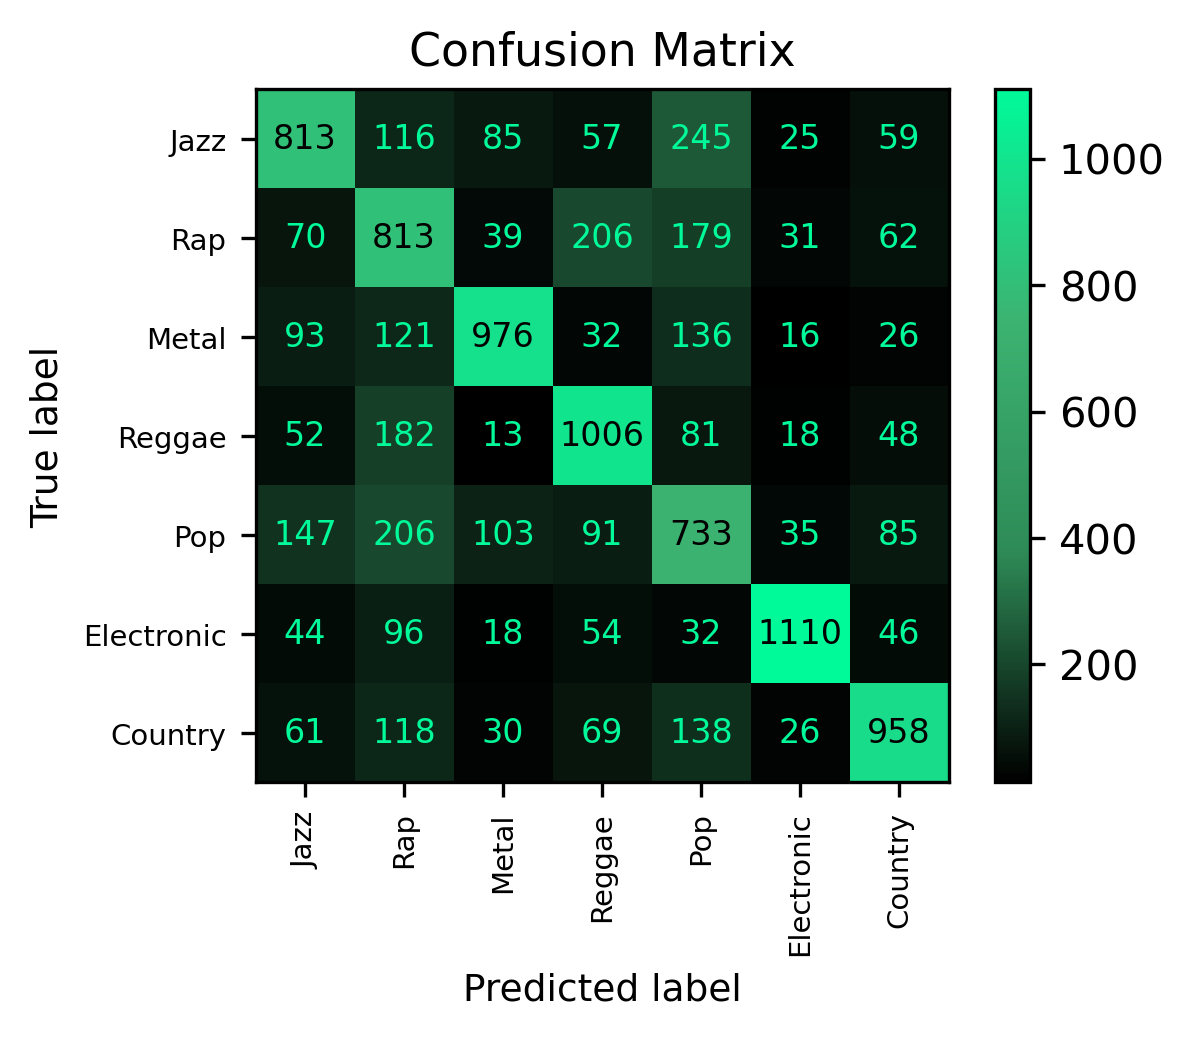

In [ ]:
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report

# sample 10000 tracks (this makes the train-test split about 50/50, but this is just to showcase the performance differences between different kernels)
i = np.random.choice(train_X_tfidf.shape[0], size=10000, replace=False)
train_X_sample = train_X_tfidf[i]
train_y_sample = train_y.iloc[i]

def run_svc(model, name):
    # fit (uses one-vs-one)
    model.fit(train_X_sample, train_y_sample)

    # predict
    pred_y = model.predict(test_X_tfidf)

    # results
    accuracy = accuracy_score(test_y, pred_y)
    f1 = f1_score(test_y, pred_y, average='macro')

    print(f'{name}')
    print(f'\tAccuracy: {accuracy:.3f}')
    print(f'\tAverage F1: {f1:.3f}\n')
    print(classification_report(test_y, pred_y, target_names=y.unique()))
    plot_confusion_matrix(test_y, pred_y)

# Linear
run_svc(
    SVC(kernel='linear'), 
    'Linear Kernel'
)

# RBF
run_svc(
    SVC(kernel='rbf'), 
    'RBF Kernel'
)

# Polynomial
run_svc(
    SVC(kernel='poly', degree=2), 
    'Polynomial Kernel with degree of 2'
)

### Use LinearSVC to predict genre based on lyrics (optimized for large datasets)

Accuracy: 0.652
Average F1: 0.651

              precision    recall  f1-score   support

        Jazz       0.63      0.61      0.62      1400
         Rap       0.54      0.52      0.53      1400
       Metal       0.66      0.70      0.68      1400
      Reggae       0.70      0.71      0.70      1400
         Pop       0.49      0.45      0.47      1400
  Electronic       0.87      0.88      0.88      1400
     Country       0.66      0.69      0.67      1400

    accuracy                           0.65      9800
   macro avg       0.65      0.65      0.65      9800
weighted avg       0.65      0.65      0.65      9800



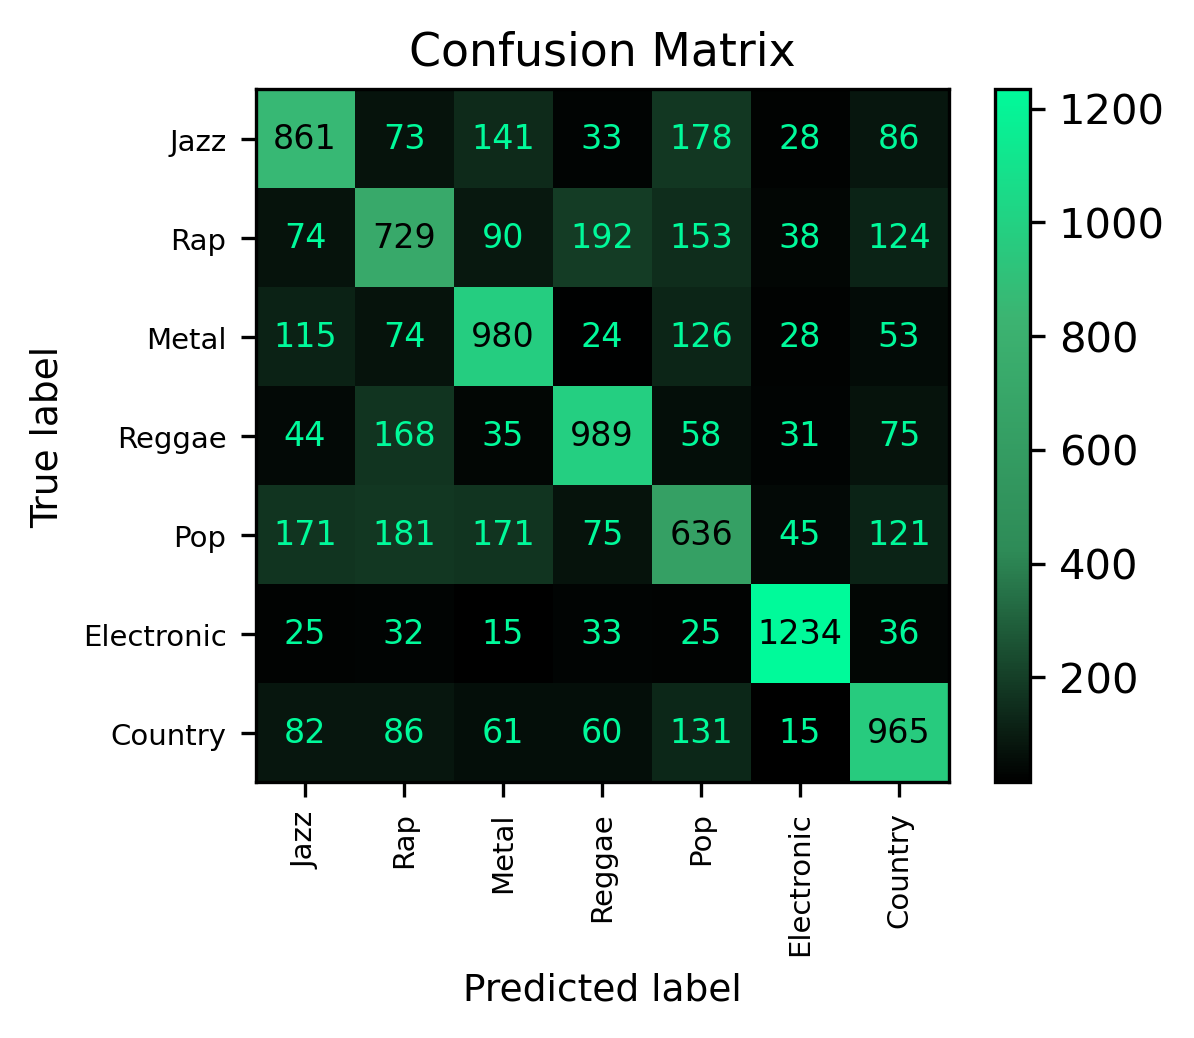

In [ ]:
from sklearn.svm import LinearSVC

# fit (uses one-vs-rest)
svm_model = LinearSVC()
svm_model.fit(train_X_tfidf, train_y)

# predict
pred_y = svm_model.predict(test_X_tfidf)

# results
accuracy = accuracy_score(test_y, pred_y)
f1 = f1_score(test_y, pred_y, average='macro')

print(f'Accuracy: {accuracy:.3f}')
print(f'Average F1: {f1:.3f}\n')
print(classification_report(test_y, pred_y, target_names=y.unique()))
plot_confusion_matrix(test_y, pred_y)

This performs slightly better than SVC(kernel='linear'), but much faster. It still performs slightly worse than SVC(kernel='rbf'), which is somewhat expected since it is using linear decision boundaries on very complicated, high dimensional data. In general the SVMs struggle with separating the genre labels, which is likely due to the high dimensionality of the data. However, using the weights of the hyperplanes formed by the LinearSVC SVM, we can see which words correspond positively and negatively to each class.

### Interpretation

Looking at the most defining positive and negative features of each class is really interesting (there is some explicit language). For example, it makes sense that the class `Country` would positively weigh lyrics like 'honki' and 'porch' (honki is the stemmed version of honky), and negatively weight lyrics like 'jamaica'. It also makes sense that `Jazz` would positively weigh 'samba', and that `Rap` would positively weigh 'brooklyn' and 'rhyme'. 

In [257]:
# weights of the hyperplanes (how much each word affects the hyperplane of a class)
coefs = svm_model.coef_

# the features (words)
feature_names = count_vectorizer.get_feature_names_out().tolist()

labels = svm_model.classes_

top_n = 3

for i in range(len(labels)):
    label = labels[i]
    coef = coefs[i]

    top_n_positive = np.argsort(coef)[-top_n:]
    top_n_negative = np.argsort(coef)[:top_n]

    print(f'\n{label}:')
    for j in reversed(top_n_positive):
        print(f'{coef[j]:.2f}\t{feature_names[j]}')
    for j in top_n_negative:
        print(f'{coef[j]:.2f}\t{feature_names[j]}')



Country:
4.84	honki
3.83	instrument
2.86	porch
-3.16	fuckin
-3.05	jamaica
-3.04	fuck

Electronic:
2.51	virus
2.08	centuri
1.86	glisten
-2.78	jean
-2.65	beef
-2.36	rollin

Jazz:
3.69	chart
2.84	wealth
2.80	samba
-2.80	porch
-2.74	jukebox
-2.65	alreadi

Metal:
2.71	damnat
2.46	manipul
2.20	parasit
-2.98	thug
-2.82	walkin
-2.69	yall

Pop:
2.04	musiqu
2.00	coeur
1.94	cancion
-2.24	isso
-2.14	glisten
-2.11	honki

Rap:
3.84	pimp
3.30	rhyme
3.11	brooklyn
-4.09	inna
-2.46	crime
-2.20	chart

Reggae:
5.98	inna
3.26	isso
2.52	miser
-2.98	vote
-2.64	neighborhood
-2.62	yell


### LightGBM Boosting

In [138]:
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


I found that a learning rate of 0.05 was a good balance between speed and performance, and I also played around with `num_leaves` and `n_estimators` (tried to not make the model too complex, but still wanted good performance). 

I create another train-test (train-validation) split on the previous training set so that the model can use the validation set during training and the test set afterward. This model might be overfitting, but this would need to be verified using cross validation, which I do not do here (it does perform well on the test set which it didn't see at all during training though). 

When making this, I looked at:
1. https://www.kdnuggets.com/2023/07/lgbmclassifier-gettingstarted-guide.html
2. https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html
3. https://www.kaggle.com/code/marychin/num-leaves-min-data-in-leaf-a-lightgbm-demo

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.084365 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 176902
[LightGBM] [Info] Number of data points in the train set: 31360, number of used features: 1937
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[500]	valid_0's multi_logloss: 0.435885
Accuracy: 0.884
Average F1: 0.884

              precision    recall  f1-score   support

        Jazz       0.88      0.84      0.86      1400
         Rap       0.82      0.87   

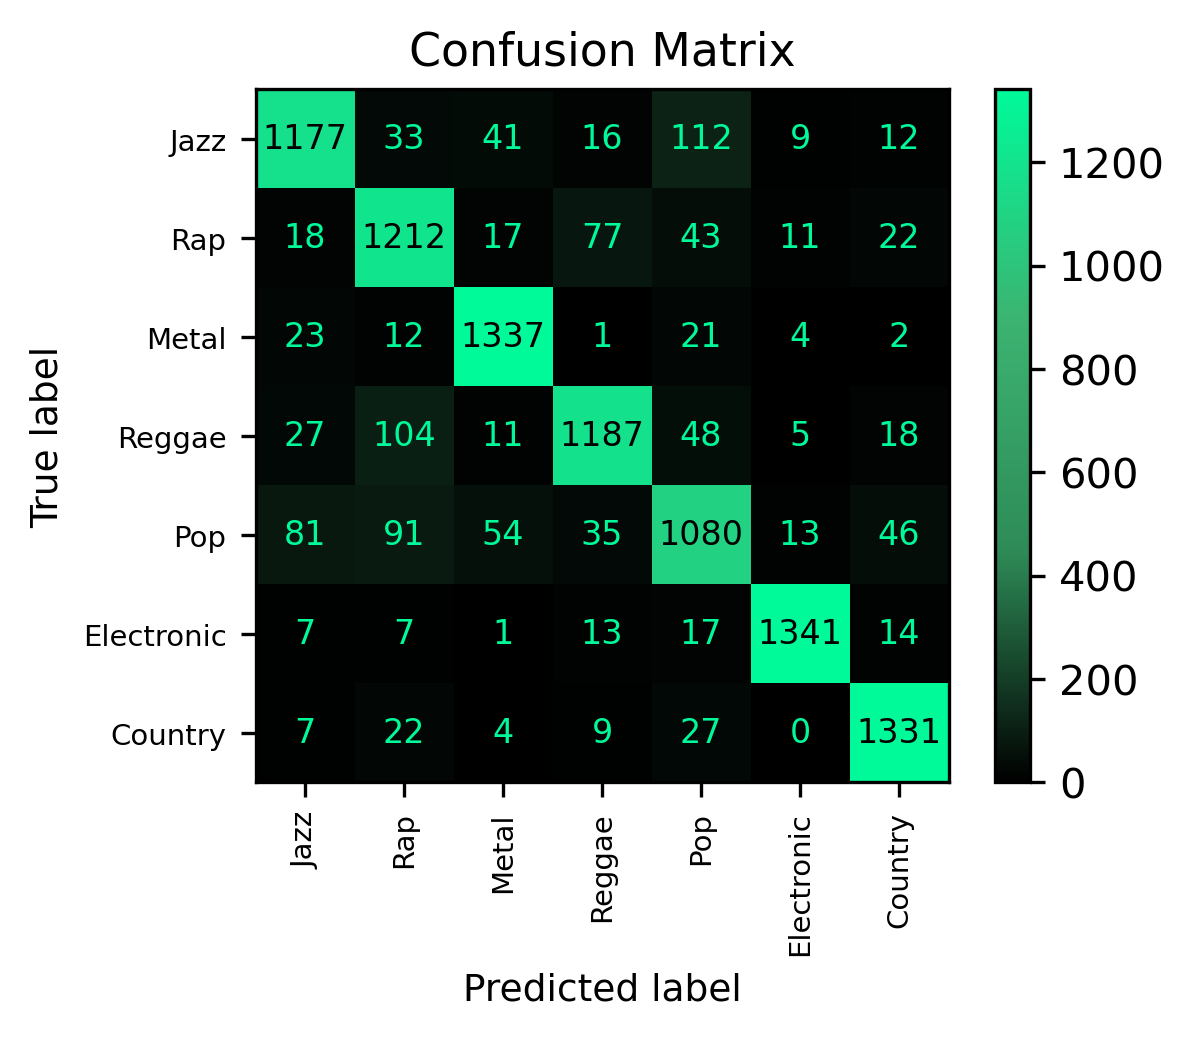

In [315]:
from lightgbm import LGBMClassifier, early_stopping

train_X_gbm, val_X, train_y_gbm, val_y = train_test_split(
    train_X_tfidf, train_y, test_size=0.2, stratify=train_y, random_state=1
)

# initialize model for multiclass classification
model = LGBMClassifier(
    objective='multiclass',
    num_class=len(val_y.unique()),
    learning_rate=0.05,
    num_leaves=40,
    n_estimators=500,
    class_weight='balanced',
    random_state=1
)

# fit
model.fit(
    train_X_gbm, train_y_gbm,
    eval_set=[(val_X, val_y)],
    eval_metric='multi_logloss',
    callbacks=[early_stopping(stopping_rounds=50)]
)

# predict
pred_y = model.predict(test_X_tfidf)

# results
accuracy = accuracy_score(test_y, pred_y)
f1 = f1_score(test_y, pred_y, average='macro')

print(f'Accuracy: {accuracy:.3f}')
print(f'Average F1: {f1:.3f}\n')
print(classification_report(test_y, pred_y, target_names=y.unique()))
plot_confusion_matrix(test_y, pred_y)

The boosted LightGBM model (which uses decision trees), had better performance than the SVMs. It had an average F1 score of 0.884, which is quite high, given that there were 7 classes. The class `Electronic` had an F1 score of 0.96, which is very high. The class with the lowest F1 score was `Pop`, which had an F1 score of 0.79. This is still quite high, given that `Pop` is a somewhat vague genre (pop songs could really be about anything, although, having looked at clusters in the dataset, most of them were about love). The model is probably overfitting though, which could be corrected with cross validation and more aggressive regularization. For now, we can test the real world performance of the classifier by seeing how it classifies lyrics we make up.

### LightGBM model prediction on unseen lyrics

This is not as effective as I want (it is biased toward electronic, and does not seem to ever really predict pop, but it's a cool demo).

In [366]:
import re
from nltk.stem import PorterStemmer

# the input needs to be stemmed to match the training data
stemmer = PorterStemmer()
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    words = text.split()
    stemmed_words = [stemmer.stem(word) for word in words]
    return ' '.join(stemmed_words)

examples = []
# pop
examples.append(['driving through the mountains, playing guitar on a summer night'])
# country
examples.append(['driving my truck through the mountains, playing guitar on a summer night'])
# metal
examples.append(['thunder rains down, blood pours from the sky'])
# rap
examples.append(['hustling through the streets of brooklyn'])
# jazz
examples.append(['train barrels past, autumn leaves, beautiful love mystery'])
# reggae
examples.append(['sunshine smiles, its a beautiful day in jamaica'])
# electronic
examples.append(['dancing in space with aliens'])

for example in examples:
    # preprocess the unseen sample
    unseen_clean = [preprocess(lyric) for lyric in example]

    unseen_bow = count_vectorizer.transform(example)
    unseen_tfidf = tfidf_transformer.transform(unseen_bow)
    unseen_tfidf = normalize(unseen_tfidf)

    # predict
    predicted = model.predict(unseen_tfidf)
    print(f'\nLyrics: {example}')
    print(f'Predicted genre: {predicted[0]}')


Lyrics: ['driving through the mountains, playing guitar on a summer night']
Predicted genre: Pop

Lyrics: ['driving my truck through the mountains, playing guitar on a summer night']
Predicted genre: Country

Lyrics: ['thunder rains down, blood pours from the sky']
Predicted genre: Metal

Lyrics: ['hustling through the streets of brooklyn']
Predicted genre: Rap

Lyrics: ['train barrels past, autumn leaves, beautiful love mystery']
Predicted genre: Jazz

Lyrics: ['sunshine smiles, its a beautiful day in jamaica']
Predicted genre: Reggae

Lyrics: ['dancing in space with aliens']
Predicted genre: Electronic
